<a href="https://colab.research.google.com/github/arturbernardo/eleicoes_fingerprint/blob/main/eleicoes_fingerprint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import drive
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.colors import LogNorm


In [51]:
pd.options.display.max_columns = None


In [ ]:
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
all = pd.DataFrame()

states = ['AC', 'AL', 'AM', 'AP', 'DF', 'ES', 'MA', 'MS', 'MG', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'SC', 'SE', 'ZZ', 'TO', 'SP', 'RS', 'CE', 'GO', 'BA']
# states = ['BA']

for state in states:
  st = pd.read_csv('/content/drive/MyDrive/data/eleicoes2022unziped/bweb_2t_'+state+'_311020221535.csv', encoding="ISO-8859-1", sep = ';',
                   dtype={
                            "SG_UF": pd.CategoricalDtype(),
                            "CD_MUNICIPIO": pd.Int64Dtype(),
                            "NR_LOCAL_VOTACAO": pd.Int64Dtype(),
                            "NR_ZONA": pd.Int64Dtype(),
                            "NR_SECAO": pd.CategoricalDtype()
                        })

  st_presidente = st[st.CD_CARGO_PERGUNTA == 1]
  filtered_df = st_presidente.loc[(st_presidente['NR_PARTIDO'] == 13) | (st_presidente['NR_PARTIDO'] == 22)]

  toUnion = [all, filtered_df]

  all = pd.concat(toUnion)

all


In [45]:
df = all

In [48]:

key_cols = [
    "ANO_ELEICAO", "NR_TURNO", "SG_UF", "CD_MUNICIPIO",
    "NR_ZONA", "NR_SECAO", "NR_URNA_EFETIVADA", "CD_CARGO_PERGUNTA"
]

cols = key_cols + ["NR_PARTIDO", "QT_VOTOS", "QT_APTOS", "QT_COMPARECIMENTO"]

x = df.loc[df["NR_PARTIDO"].isin([13, 22]), cols]

for c in ["ANO_ELEICAO", "NR_TURNO", "CD_MUNICIPIO", "NR_ZONA",
          "NR_SECAO", "NR_URNA_EFETIVADA", "CD_CARGO_PERGUNTA",
          "NR_PARTIDO", "QT_VOTOS", "QT_APTOS", "QT_COMPARECIMENTO"]:
    x[c] = pd.to_numeric(x[c], downcast="integer")

x["SG_UF"] = x["SG_UF"].astype("category")

v13 = x.loc[x["NR_PARTIDO"] == 13, key_cols + ["QT_VOTOS", "QT_APTOS", "QT_COMPARECIMENTO"]]
v13 = v13.rename(columns={"QT_VOTOS": "votos_13"}).drop_duplicates(subset=key_cols)

v22 = x.loc[x["NR_PARTIDO"] == 22, key_cols + ["QT_VOTOS"]]
v22 = v22.rename(columns={"QT_VOTOS": "votos_22"}).drop_duplicates(subset=key_cols)

plot_df = v13.merge(v22, on=key_cols, how="inner")
plot_df["valid_votes_2cand"] = plot_df["votos_13"] + plot_df["votos_22"]
plot_df["winner_votes"] = plot_df["votos_13"]
plot_df = plot_df[(plot_df["QT_APTOS"] > 0) & (plot_df["valid_votes_2cand"] > 0)]

plot_df["turnout_pct"] = plot_df["votos_13"] / plot_df["QT_APTOS"] * 100
plot_df["winner_pct"] = plot_df["winner_votes"] / plot_df["valid_votes_2cand"] * 100

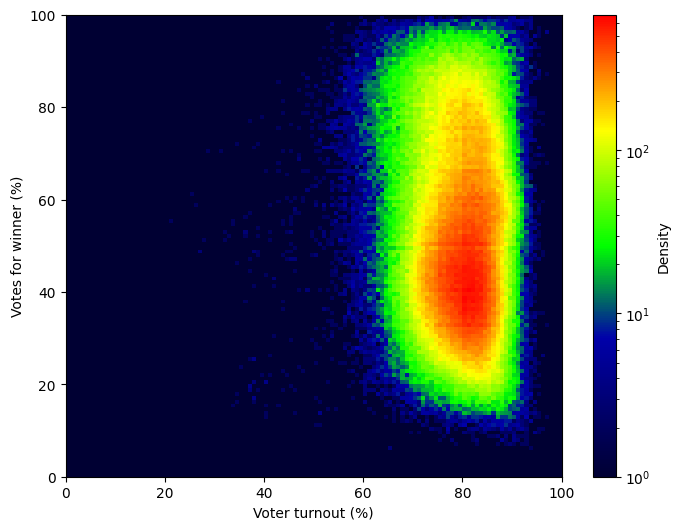

In [52]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm

colors = [
    (0.0, "#000033"),   # azul escuro (fundo)
    (0.3, "#0000AA"),   # azul
    (0.5, "#00FF00"),   # verde
    (0.75, "#FFFF00"),  # amarelo (transição)
    (1.0, "#FF0000")    # vermelho
]

cmap = LinearSegmentedColormap.from_list("blue_green_red", colors)


fingerprint_df = plot_df.rename(columns={
    "QT_APTOS": "registered_voters",
    "QT_COMPARECIMENTO": "ballots_cast",
    "valid_votes_2cand": "valid_votes",
    "winner_votes": "winner_votes"
})[["registered_voters", "ballots_cast", "valid_votes", "winner_votes"]].copy()

fingerprint_df["turnout_pct"] = (
    fingerprint_df["ballots_cast"] / fingerprint_df["registered_voters"] * 100
)

fingerprint_df["winner_pct"] = (
    fingerprint_df["winner_votes"] / fingerprint_df["valid_votes"] * 100
)

fingerprint_df = fingerprint_df[
    (fingerprint_df["registered_voters"] > 0) &
    (fingerprint_df["valid_votes"] > 0)
].copy()

plt.figure(figsize=(8, 6))
plt.hist2d(
    fingerprint_df["turnout_pct"],
    fingerprint_df["winner_pct"],
    bins=120,
    range=[[0, 100], [0, 100]],
    cmap=cmap,
    norm=LogNorm()
)
plt.colorbar(label="Density")
plt.xlabel("Voter turnout (%)")
plt.ylabel("Votes for winner (%)")
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.gca().set_facecolor("#000033")

plt.show()

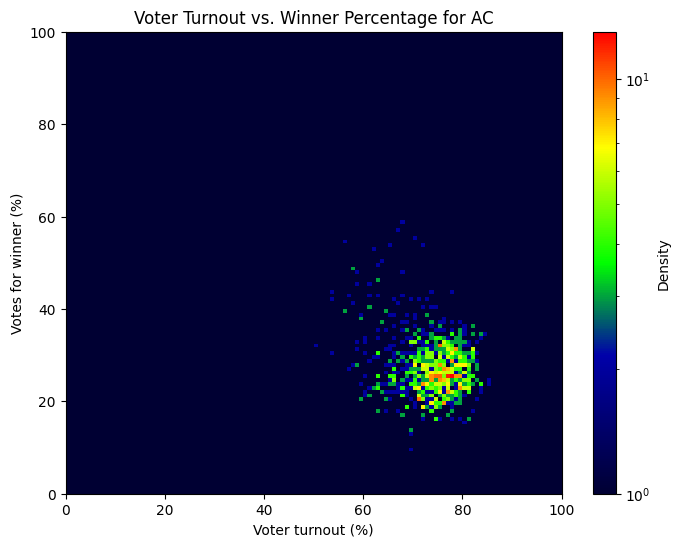

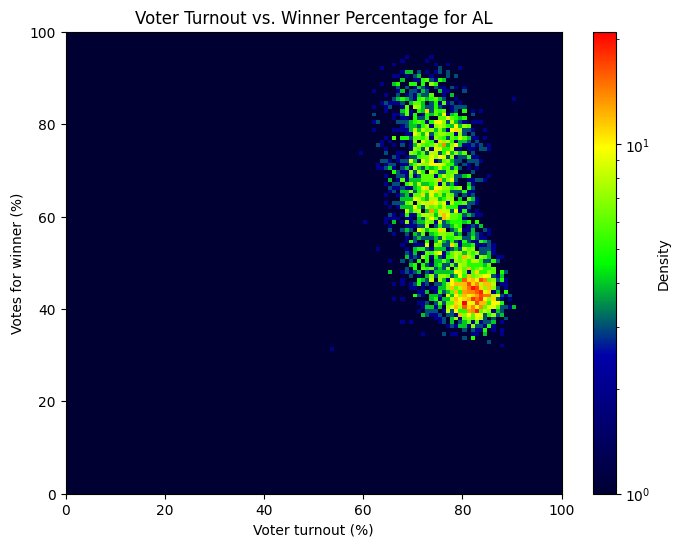

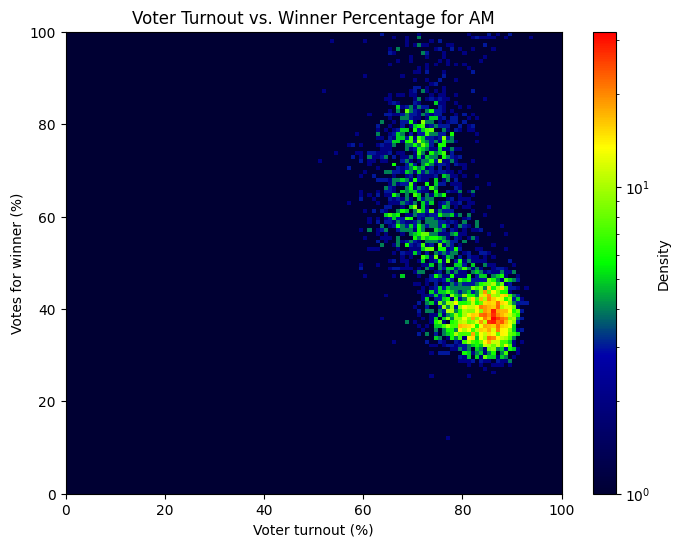

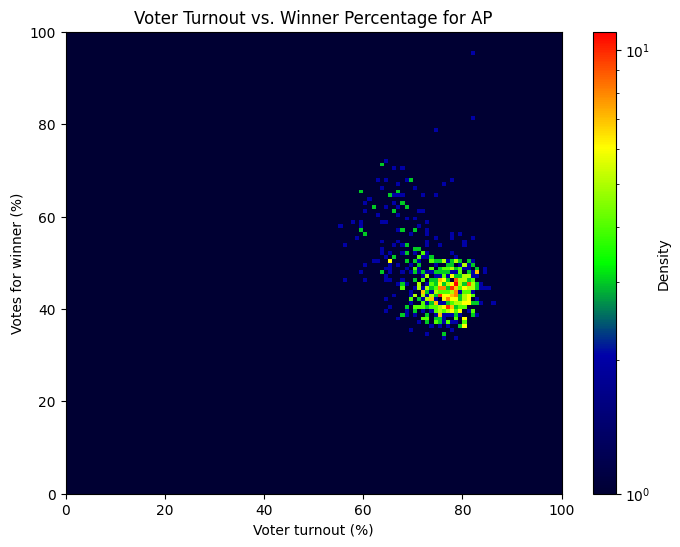

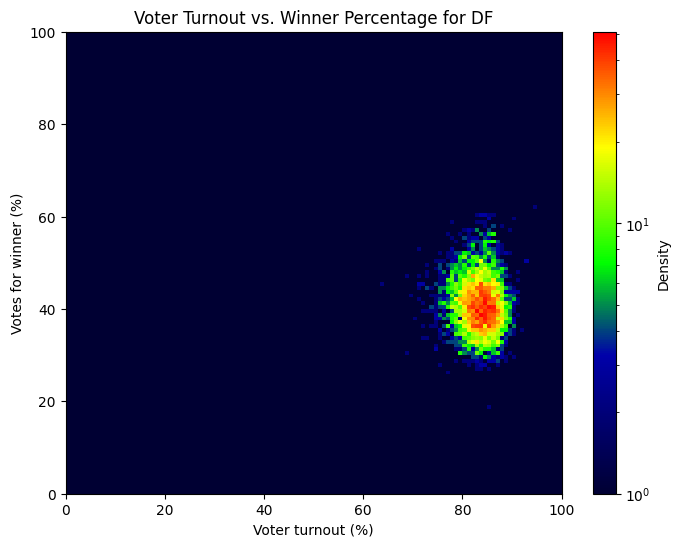

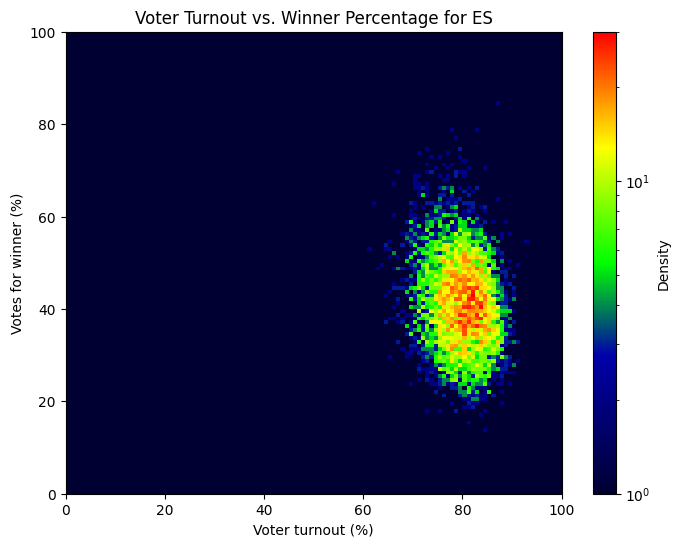

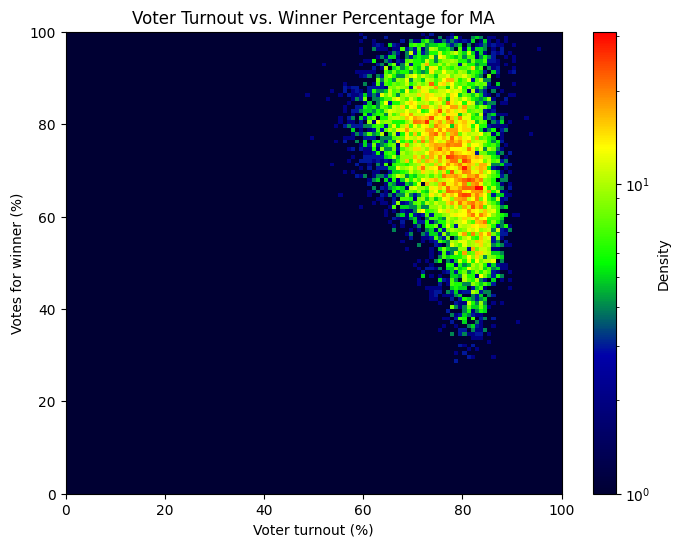

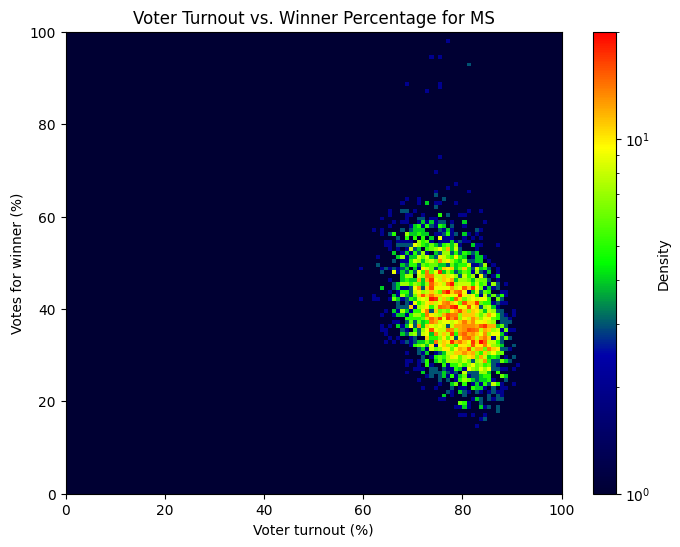

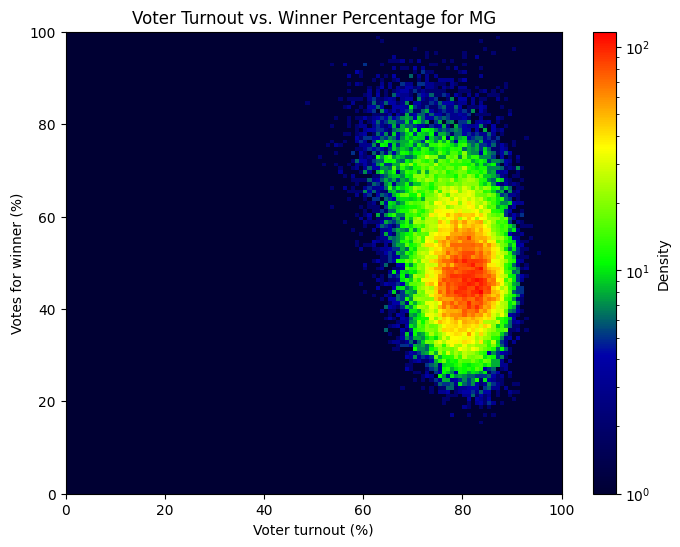

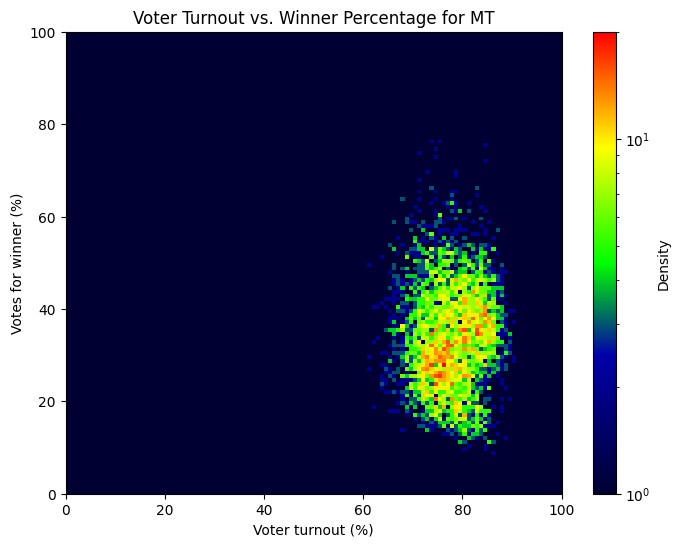

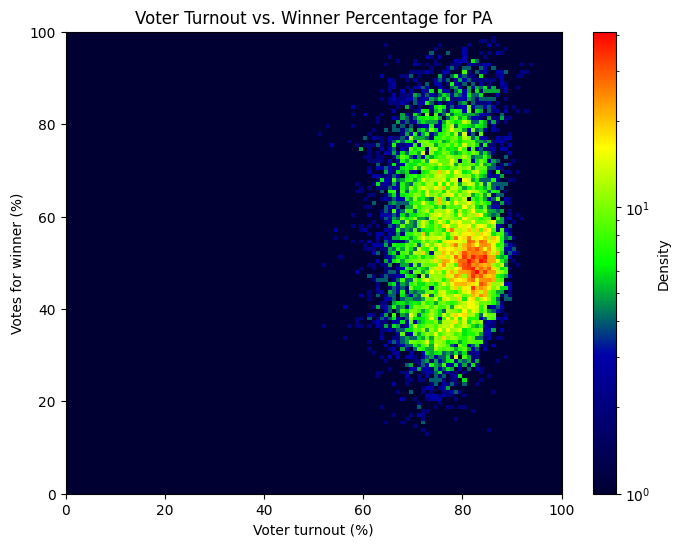

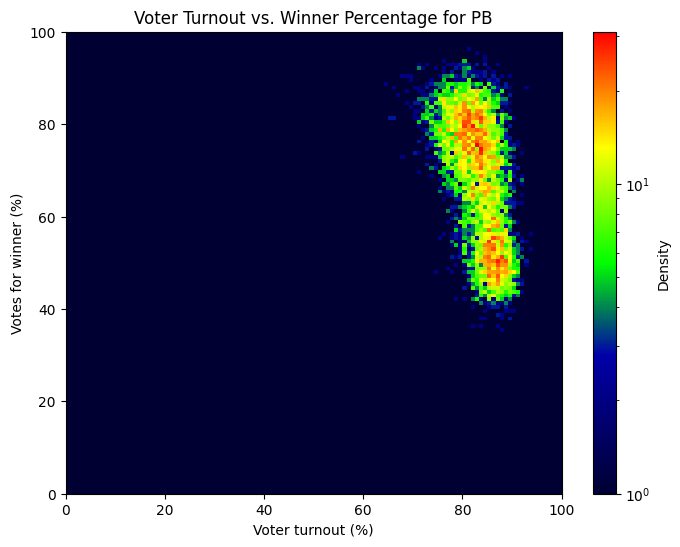

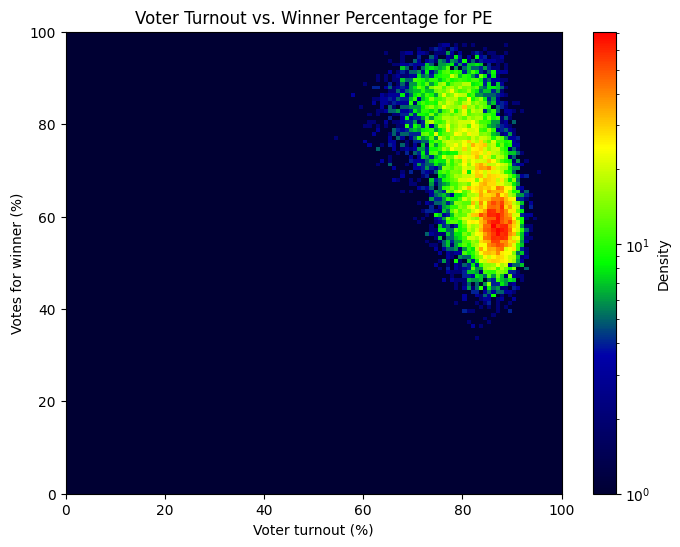

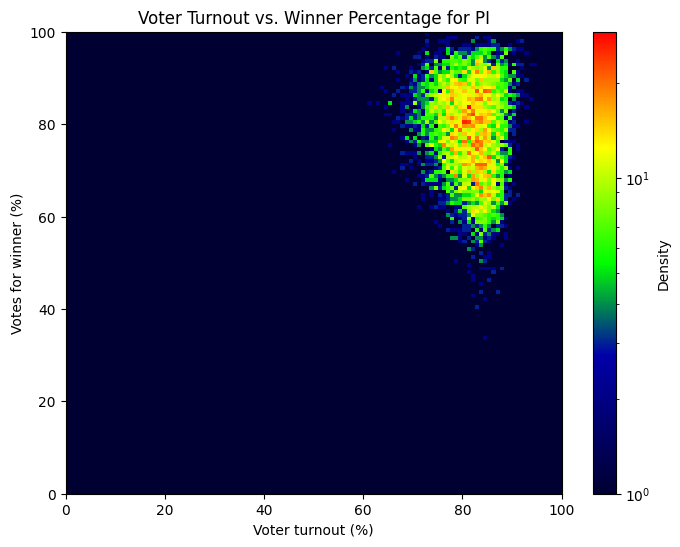

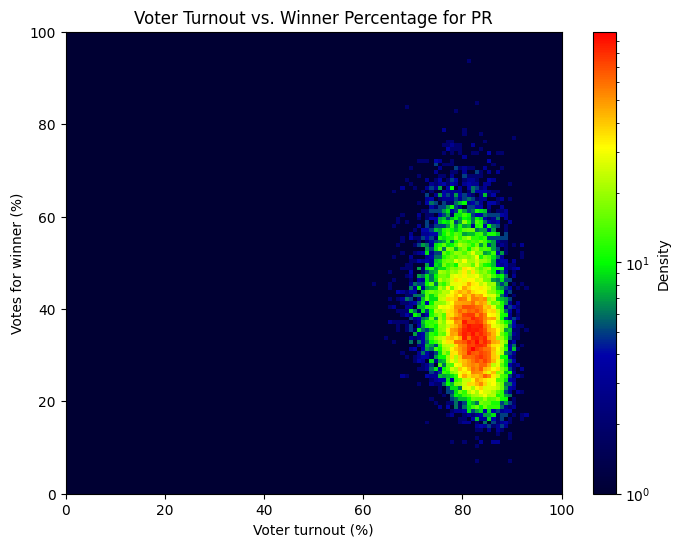

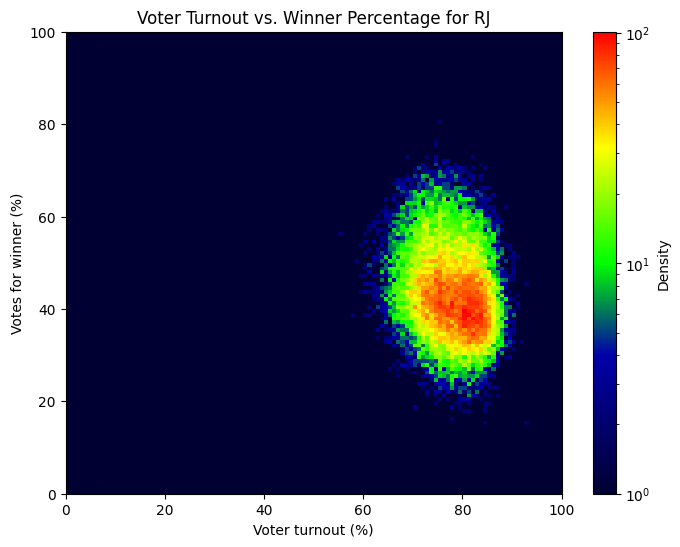

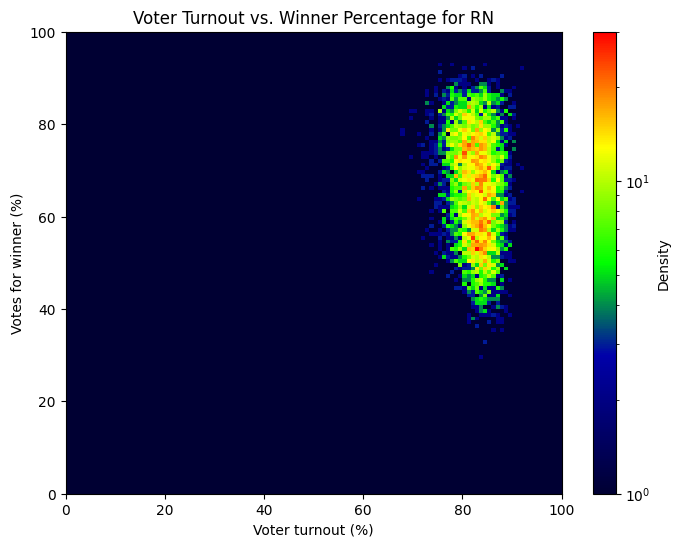

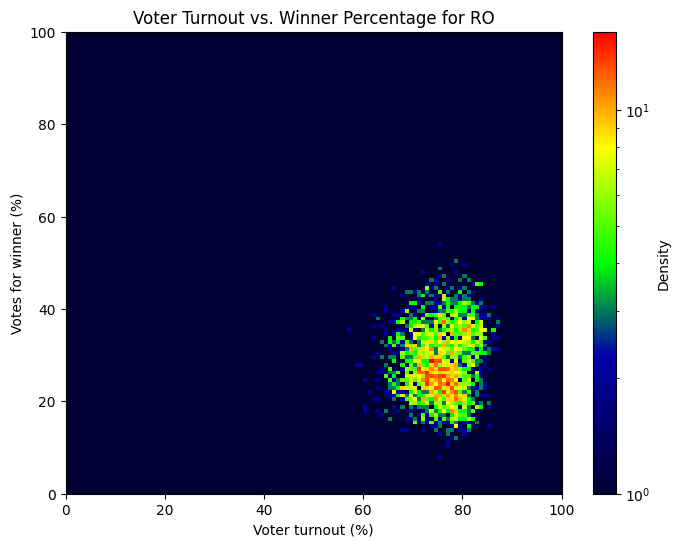

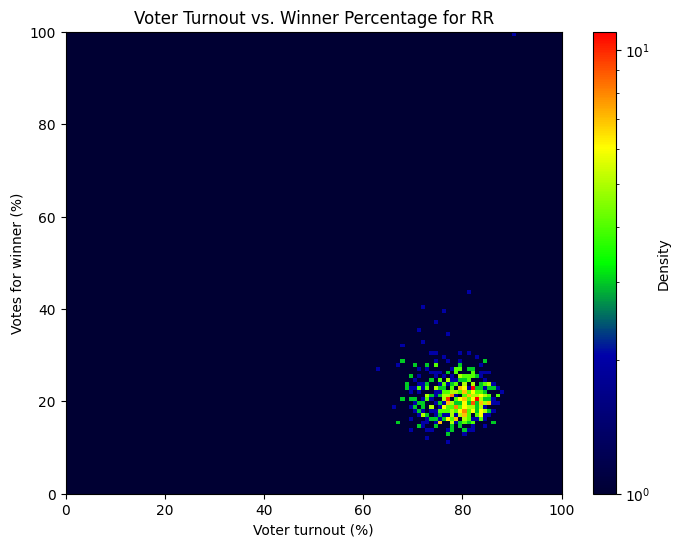

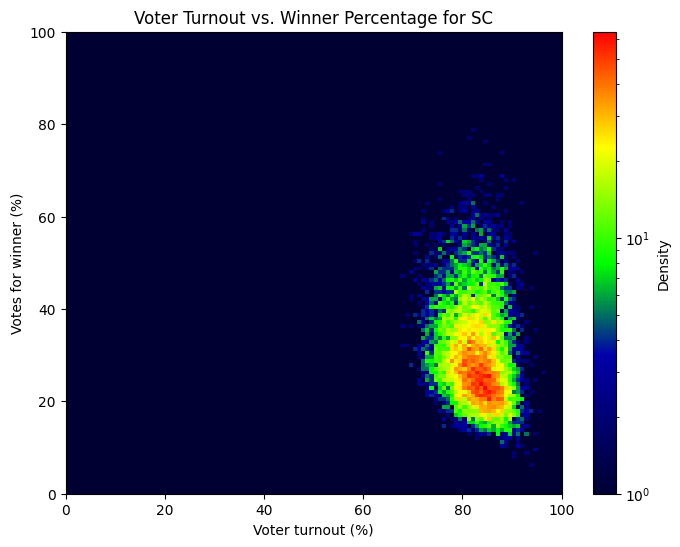

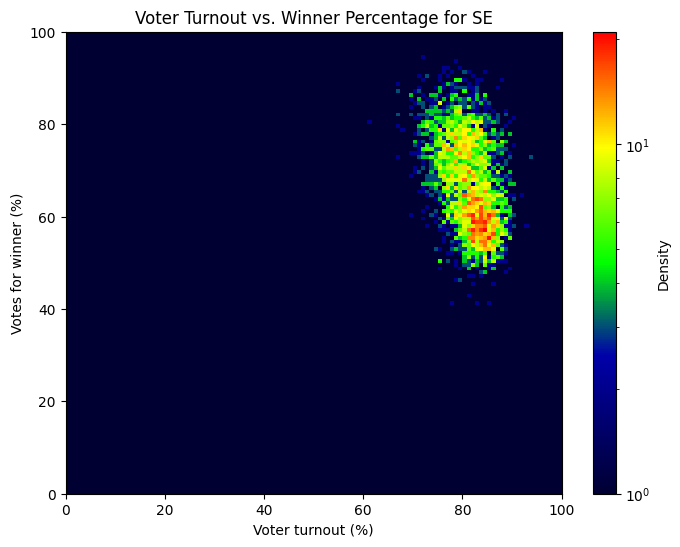

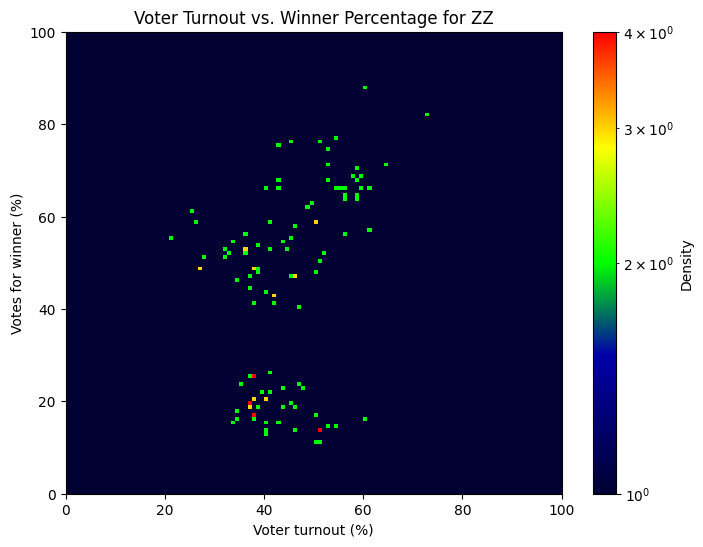

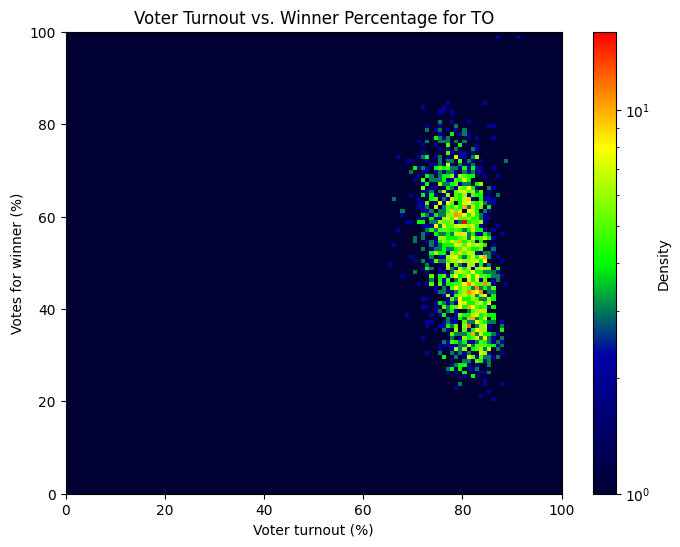

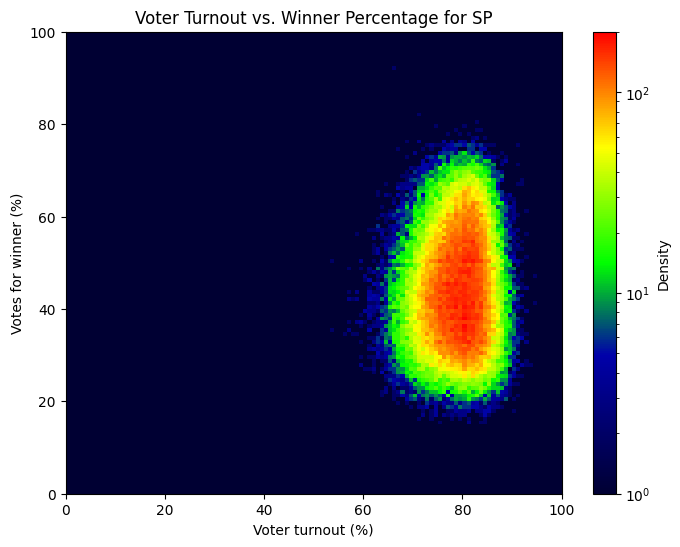

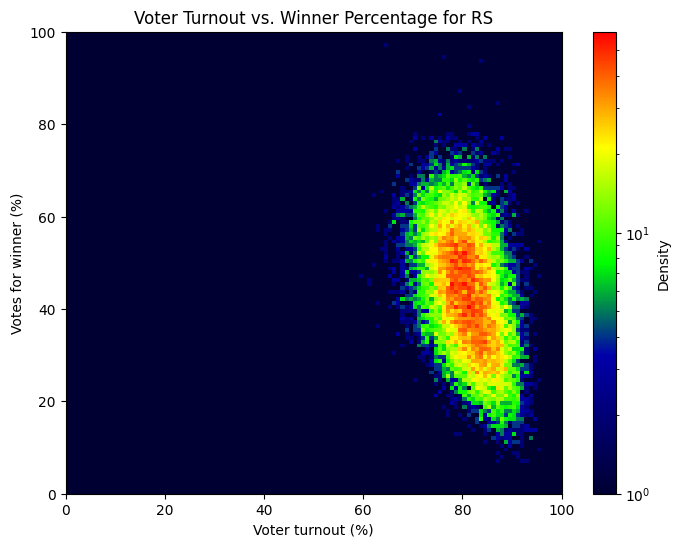

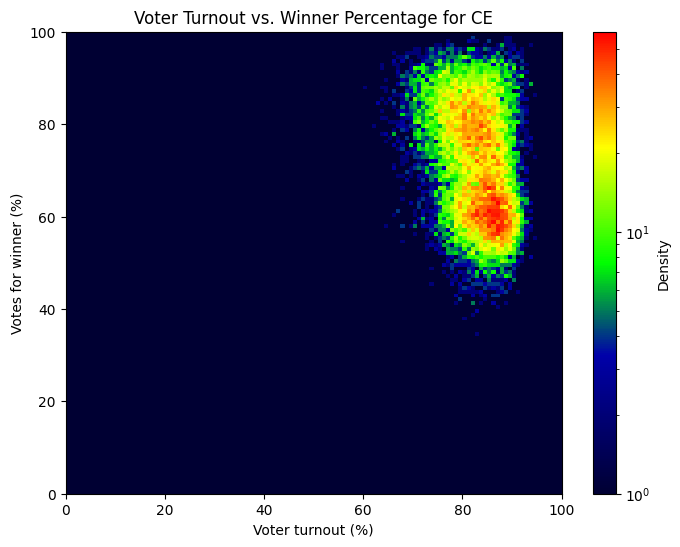

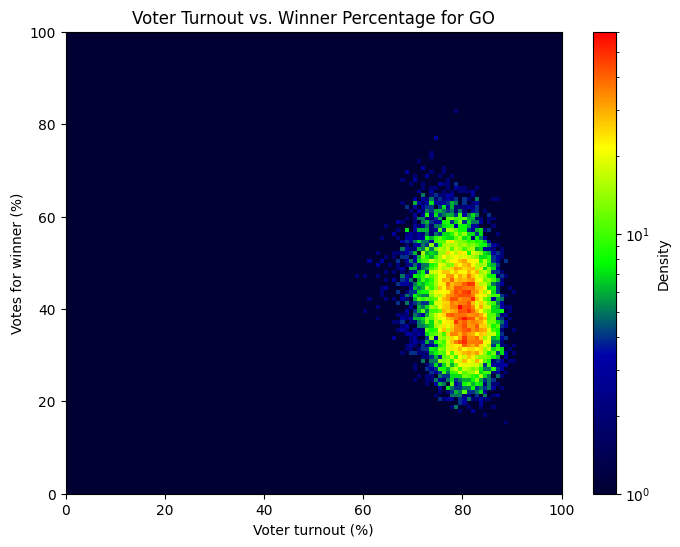

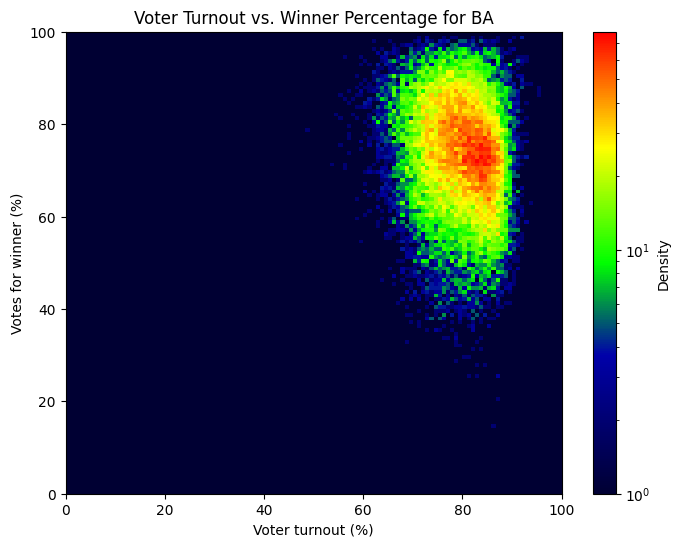

In [58]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import pandas as pd

colors = [
    (0.0, "#000033"),   # azul escuro (fundo)
    (0.3, "#0000AA"),   # azul
    (0.5, "#00FF00"),   # verde
    (0.75, "#FFFF00"),  # amarelo (transição)
    (1.0, "#FF0000")    # vermelho
]
cmap = LinearSegmentedColormap.from_list("blue_green_red", colors)

unique_states = df['SG_UF'].unique()

key_cols = [
    "ANO_ELEICAO", "NR_TURNO", "SG_UF", "CD_MUNICIPIO",
    "NR_ZONA", "NR_SECAO", "NR_URNA_EFETIVADA", "CD_CARGO_PERGUNTA"
]

cols = key_cols + ["NR_PARTIDO", "QT_VOTOS", "QT_APTOS", "QT_COMPARECIMENTO"]

for state_code in unique_states:
    df_state_specific = df[df['SG_UF'] == state_code].copy() # .copy() to avoid SettingWithCopyWarning

    x_state = df_state_specific.loc[df_state_specific["NR_PARTIDO"].isin([13, 22]), cols]

    for c in ["ANO_ELEICAO", "NR_TURNO", "CD_MUNICIPIO", "NR_ZONA",
              "NR_SECAO", "NR_URNA_EFETIVADA", "CD_CARGO_PERGUNTA",
              "NR_PARTIDO", "QT_VOTOS", "QT_APTOS", "QT_COMPARECIMENTO"]:
        x_state[c] = pd.to_numeric(x_state[c], downcast="integer", errors='coerce')

    x_state["SG_UF"] = x_state["SG_UF"].astype("category")

    v13_state = x_state.loc[x_state["NR_PARTIDO"] == 13, key_cols + ["QT_VOTOS", "QT_APTOS", "QT_COMPARECIMENTO"]]
    v13_state = v13_state.rename(columns={"QT_VOTOS": "votos_13"}).drop_duplicates(subset=key_cols)

    v22_state = x_state.loc[x_state["NR_PARTIDO"] == 22, key_cols + ["QT_VOTOS"]]
    v22_state = v22_state.rename(columns={"QT_VOTOS": "votos_22"}).drop_duplicates(subset=key_cols)

    plot_df_state_specific = v13_state.merge(v22_state, on=key_cols, how="inner")
    plot_df_state_specific["valid_votes_2cand"] = plot_df_state_specific["votos_13"] + plot_df_state_specific["votos_22"]
    plot_df_state_specific["winner_votes"] = plot_df_state_specific["votos_13"]

    plot_df_state_specific = plot_df_state_specific[(plot_df_state_specific["QT_APTOS"] > 0) & (plot_df_state_specific["valid_votes_2cand"] > 0)]

    plot_df_state_specific["turnout_pct"] = plot_df_state_specific["QT_COMPARECIMENTO"] / plot_df_state_specific["QT_APTOS"] * 100
    plot_df_state_specific["winner_pct"] = plot_df_state_specific["winner_votes"] / plot_df_state_specific["valid_votes_2cand"] * 100

    plt.figure(figsize=(8, 6))
    plt.hist2d(
        plot_df_state_specific["turnout_pct"],
        plot_df_state_specific["winner_pct"],
        bins=120,
        range=[[0, 100], [0, 100]],
        cmap=cmap,
        norm=LogNorm()
    )
    plt.colorbar(label="Density")
    plt.xlabel("Voter turnout (%)")
    plt.ylabel("Votes for winner (%)")
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.title(f"Voter Turnout vs. Winner Percentage for {state_code}")
    plt.gca().set_facecolor("#000033")
    plt.show()